# Load Data

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.decomposition import PCA

VARIANCE_PERCENTILE_THRESHOLD = 10   # features with var < this are dropped
MAHAL_ALPHA        = 0.001  # chi² significance level for outlier cutoff# (smaller = less aggressive removal)
PRELIM_MAX_ITER    = 1000

# Load datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()
test.head()

Train shape: (886, 12044)
Test shape: (379, 12043)


,id,RNF14,UBE2Q1,RNF17,RNF10,RNF11,RNF13,REM1,TSKS,NDP,...,SELE,SLC7A10,SLC7A11,FOLR1,NPY5R,GNGT1,PTRF,SERPINH1,NFIX,SELP
0,S1934300,5.926539,9.009568,3.541168,6.065521,8.209993,7.638964,4.379268,3.284873,4.452102,...,3.096147,3.223338,3.928776,9.817659,2.980484,3.524956,6.833890,8.885565,3.601507,4.056429
1,S4277303,6.436818,9.186283,4.380652,6.687350,8.830286,9.573471,4.840425,3.877222,7.975294,...,3.451866,4.313184,5.929722,3.949647,4.149159,3.663116,5.780864,7.202803,6.445153,4.248480
2,S1105960,6.962961,9.600555,3.979856,6.830876,9.852751,9.646753,4.923072,3.441376,3.627100,...,3.588703,3.437235,4.835013,3.289477,3.418364,3.964282,8.942296,10.279120,3.695364,4.054848
3,S5828168,8.102109,9.535052,4.149430,7.142845,9.563294,9.552312,5.493155,3.843558,7.573155,...,3.634999,4.025566,6.551839,5.313923,3.704665,3.597485,7.669665,10.835452,5.551959,4.519561
4,S7570807,6.142042,9.043705,3.542552,6.510042,8.011848,8.165747,4.259402,3.115964,6.952963,...,2.794546,3.353974,5.112425,8.647404,3.231895,2.857143,5.395940,7.264292,4.382580,3.423543


# Separate Features and Target

In [100]:
X = train.drop(columns=["id", "cancer"])
y = train["cancer"]

X_test = test.drop(columns=["id"])

# Low Variance Feature Removal
    - Fit train data only, and then transform both
    - Using VarianceThreshold
    - Since data is log-transformed use small threshold like 0.01
    - We removed near-zero variance genes to reduce noise and improve model stability in the high-dimensional setting.

In [101]:
variances = X.var()

print(variances.describe())

count    12042.000000
mean         0.830792
std          1.061677
min          0.052552
25%          0.292792
50%          0.525417
75%          0.904438
max         19.023686
dtype: float64


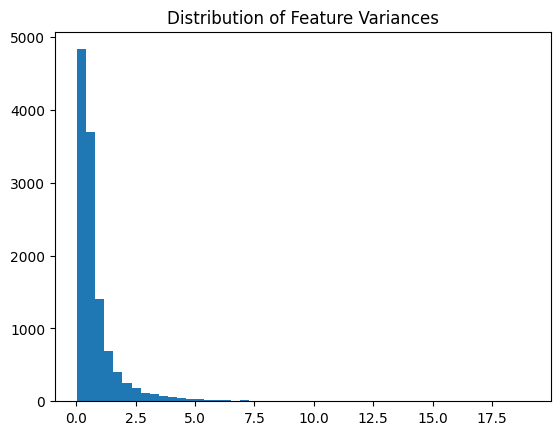

In [102]:
plt.hist(variances, bins=50)
plt.title("Distribution of Feature Variances")
plt.show()

In [103]:
threshold = np.percentile(variances, VARIANCE_PERCENTILE_THRESHOLD)
print(threshold)

0.1655183401077742


In [104]:
selector = VarianceThreshold(threshold=threshold)

# removing 10th percentile

# Fit on training data only

X_var = selector.fit_transform(X)

# Apply same transformation to test
X_test_var = selector.transform(X_test)

print("Original features:", X.shape[1])
print("Remaining features:", X_var.shape[1])

Original features: 12042
Remaining features: 10832


# Noise Detection and Handling

- identification: Samples that simultaneously satisfy the conditions of "extremely far distance" in Mahalanobis distance and "extremely low prediction probability" in preliminary training model are labeled as noise.
- Processing: High-confidence samples are directly relabeled; low-confidence samples are discarded.

##### Scale Features for Mahalanobis & preliminary model

In [105]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)
n_samples = X_scaled.shape[0]

##### Preliminary L2 Multinomial Logistic Regression
used only to generate predicted labels for the noise-detection step

In [106]:
prelim_model = LogisticRegression(solver = "lbfgs",
                                  max_iter = PRELIM_MAX_ITER,
                                  C = 1.0,
                                  random_state = 42,
                                  l1_ratio=0) # penalty = L2)
prelim_model.fit(X_scaled,y)
probs = prelim_model.predict_proba(X_scaled)

In [107]:
# obtain the prediction probability for each observation
label_map = {l: i for i, l in enumerate(prelim_model.classes_)}
given_label_probs = np.array([
    probs[i, label_map[y.iloc[i]]]
    for i in range(n_samples)
])

Mahalanobis Distance

In [108]:
def mahal_distances_for_class_robust(x_class: np.ndarray, variance_threshold = 0.95)->np.ndarray:
    """
    return Mahalanobis distance for each row in X_class from the class centroid
    """
    n_samples, n_features = x_class.shape

    # check to see if it needs dimension reduction
    if n_features >= n_samples:
        max_component = n_samples -1

        pca = PCA(n_components = variance_threshold, svd_solver = "full")

        x_reduced = pca.fit_transform(x_class)

        x_to_use = x_reduced
    else:
        x_to_use = x_class

    mean_vec = x_to_use.mean(axis = 0)
    cov = np.cov(x_to_use, rowvar = False)

    # regularise covariance to avoid singularity
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov)

    dists = np.array([mahalanobis(row, mean_vec, cov_inv) for row in x_to_use] )
    return dists

In [109]:
# $\chi^2$ critical value: df = number of features
df_chi2 = X_scaled.shape[1]
chi2_cutoff = chi2.ppf(1 - MAHAL_ALPHA, df=df_chi2)
print(f"χ²({df_chi2}, α={MAHAL_ALPHA}) cutoff = {chi2_cutoff:.2f}")

χ²(10832, α=0.001) cutoff = 11292.55


In [110]:
mahal_dists = np.zeros(n_samples)

unique_classes = y.unique()
for cls in unique_classes:
    # Get the sample index belonging to the current class
    mask = (y == cls)
    indices = np.where(mask)[0]

    if len(indices) < 2:
        # # The sample size is too small to calculate the covariance. Skip or set it to 0.
        continue

    # Extract all sample data (already standardized) for this class.
    X_class = X_scaled[mask]

    # Calculate the Mahalanobis distance within this class.
    dists_class = mahal_distances_for_class_robust(X_class, variance_threshold=0.95)

    # Fill the calculation results back into the total array.
    mahal_dists[indices] = dists_class

directly use the 99.5th percentile of the distance value as the standard for "extremely far".

In [111]:
dist_threshold = np.percentile(mahal_dists, 99.5)

Probability threshold: the level that the predicted probability considered "extremely low"

In [112]:
prob_threshold = 0.3

Identify Noise

### Conditions: Distance > Threshold AND Probability < Threshold

In [113]:
is_noise = (mahal_dists > dist_threshold) & (given_label_probs < prob_threshold)

noise_indices = np.where(is_noise)[0]
clean_indices = np.where(~is_noise)[0]

print(f"Total samples: {n_samples}")
print(f"Noise samples detected: {len(noise_indices)} ({len(noise_indices)/n_samples:.2%})")
print(f"Clean samples retained: {len(clean_indices)}")

Total samples: 886
Noise samples detected: 0 (0.00%)
Clean samples retained: 886


### Visualized noise detection effect

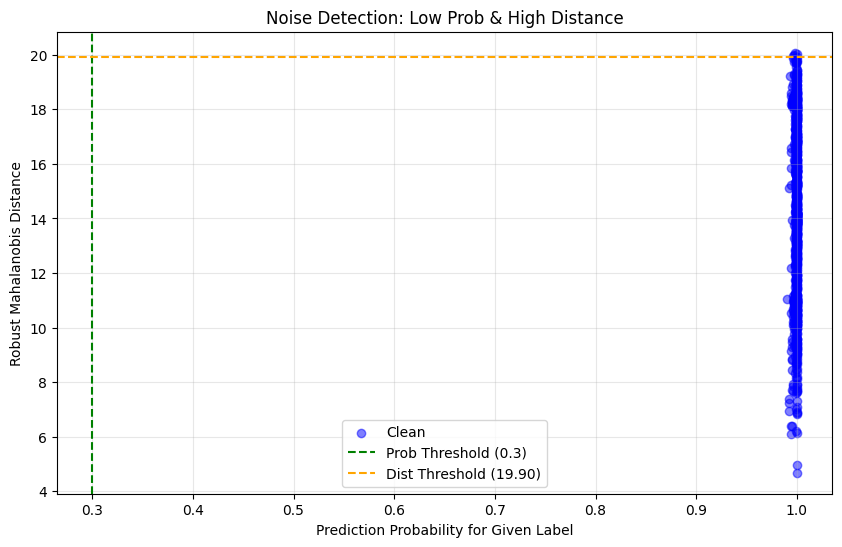

In [114]:
plt.figure(figsize=(10, 6))
plt.scatter(given_label_probs, mahal_dists, c='blue', alpha=0.5, label='Clean')
if len(noise_indices) > 0:
    plt.scatter(given_label_probs[noise_indices], mahal_dists[noise_indices],
                c='red', alpha=0.8, label='Detected Noise', edgecolors='k')
plt.axvline(prob_threshold, color='green', linestyle='--', label=f'Prob Threshold ({prob_threshold})')
plt.axhline(dist_threshold, color='orange', linestyle='--', label=f'Dist Threshold ({dist_threshold:.2f})')
plt.xlabel("Prediction Probability for Given Label")
plt.ylabel("Robust Mahalanobis Distance")
plt.title("Noise Detection: Low Prob & High Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Build the cleaned dataset

In [115]:
X_clean = X_scaled[clean_indices]
y_clean = y.iloc[clean_indices].reset_index(drop=True) # 重置索引

print(f"Training will proceed with {X_clean.shape[0]} samples and {X_clean.shape[1]} features.")

Training will proceed with 886 samples and 10832 features.


# Hyperparameter Tuning with Cross-Validation
(CV: Select Elastic Net Parameters)

##### Objective: Find the optimal alpha (regularization strength C) and l1_ratio (L1 vs L2 ratio)

##### Method: Use Stratified K-Fold CV to ensure class balance

##### Model: LogisticRegression with penalty='elasticnet' (sklearn >= 0.23) or SGDClassifier

##### Note: sklearn's LogisticRegression supports Elasticnet, but the solver must be 'saga'

In [116]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [117]:
# Define the parametric mesh
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'l1_ratio': [0.5, 0.9, 0.95] # prefer L1 for feature selection
}

# Basic Model Settings
# FIX: Removed 'multi_class' argument as it is deprecated/removed in sklearn >= 1.5
# The model now automatically handles multinomial classification.
base_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=5000,      # More iterations needed to converge for elasticnet
    random_state=42,
    n_jobs=-1
)

# Cross-validation strategy: 5 folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
# Note: n_jobs=-1 here parallelizes the CV folds, not the model fitting itself
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,          # Parallelize the grid search across folds
    verbose=1,
    refit=True          # Automatically retrain on full cleaning data using optimal parameters
)

# Perform search
grid_search.fit(X_clean, y_clean)

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Obtain the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits


KeyboardInterrupt: 

### Prediction on Test Set

Steps:

 1. Apply preprocessing to the test set (VarianceThreshold -> StandardScaler)

Note: The selector and scaler fitted to the training set must be used; refitting is not allowed!

2. Make predictions using the best model

3. Generate submission files

In [118]:
# 1. Preprocess the test set (reuse the transformer from the training set)

# X_test_var has already been generated using selector.transform in the previous code

# Now only scaling is needed
X_test_scaled = scaler.transform(X_test_var) # Use the previously fit scaler

#2. Prediction
y_pred_test = best_model.predict(X_test_scaled)
y_prob_test = best_model.predict_proba(X_test_scaled)



Prediction on Test Set

In [119]:
submission = pd.DataFrame({
    'id': test['id'],
    'cancer': y_pred_test
})

submission.to_csv("submission_final.csv", index=False)
print("Predictions saved to 'submission_final.csv'")
print(submission['cancer'].value_counts())

Predictions saved to 'submission_final.csv'
cancer
3    173
1    159
2     47
Name: count, dtype: int64


# Feature Importance Analysis

Decomposition of coefficient matrix: Analyze separately for each cancer type.

Ranking and filtering: Identify the genes that contribute the most to positive prediction for a specific category (Top Positive Markers).


--- Top 20 Markers for Cancer Type 1 ---
TREML2     0.302560
SEMA3A     0.211881
KLHL24     0.178276
DKK1       0.161882
PPBP       0.141303
BAI1       0.138306
GPR23      0.137489
OGN        0.126236
SLC16A8    0.125807
ST20       0.120342
CXCL11     0.119919
DAZ4       0.117737
SYF2       0.114721
SUHW2      0.114260
RNF39      0.111261
ZSCAN21    0.110160
MDM4       0.105712
REPS2      0.104492
MC4R       0.098238
HLA.DMB    0.094572
Name: Class_1, dtype: float64

--- Top 20 Markers for Cancer Type 2 ---
TACSTD2    0.323529
PDE1A      0.242384
MCTP2      0.215780
EGF        0.170026
CD207      0.143420
PAH        0.122383
HCG9       0.118418
ALDH3B2    0.112277
PPP1R11    0.103289
IL1A       0.102743
KLF8       0.102434
HMGN1      0.090968
C7orf16    0.084710
NUP54      0.082849
BHMT2      0.081744
POF1B      0.074257
NME4       0.071898
CHRNA1     0.071587
HOXC11     0.061473
PRRX2      0.055314
Name: Class_2, dtype: float64

--- Top 20 Markers for Cancer Type 3 ---
SELENBP1      

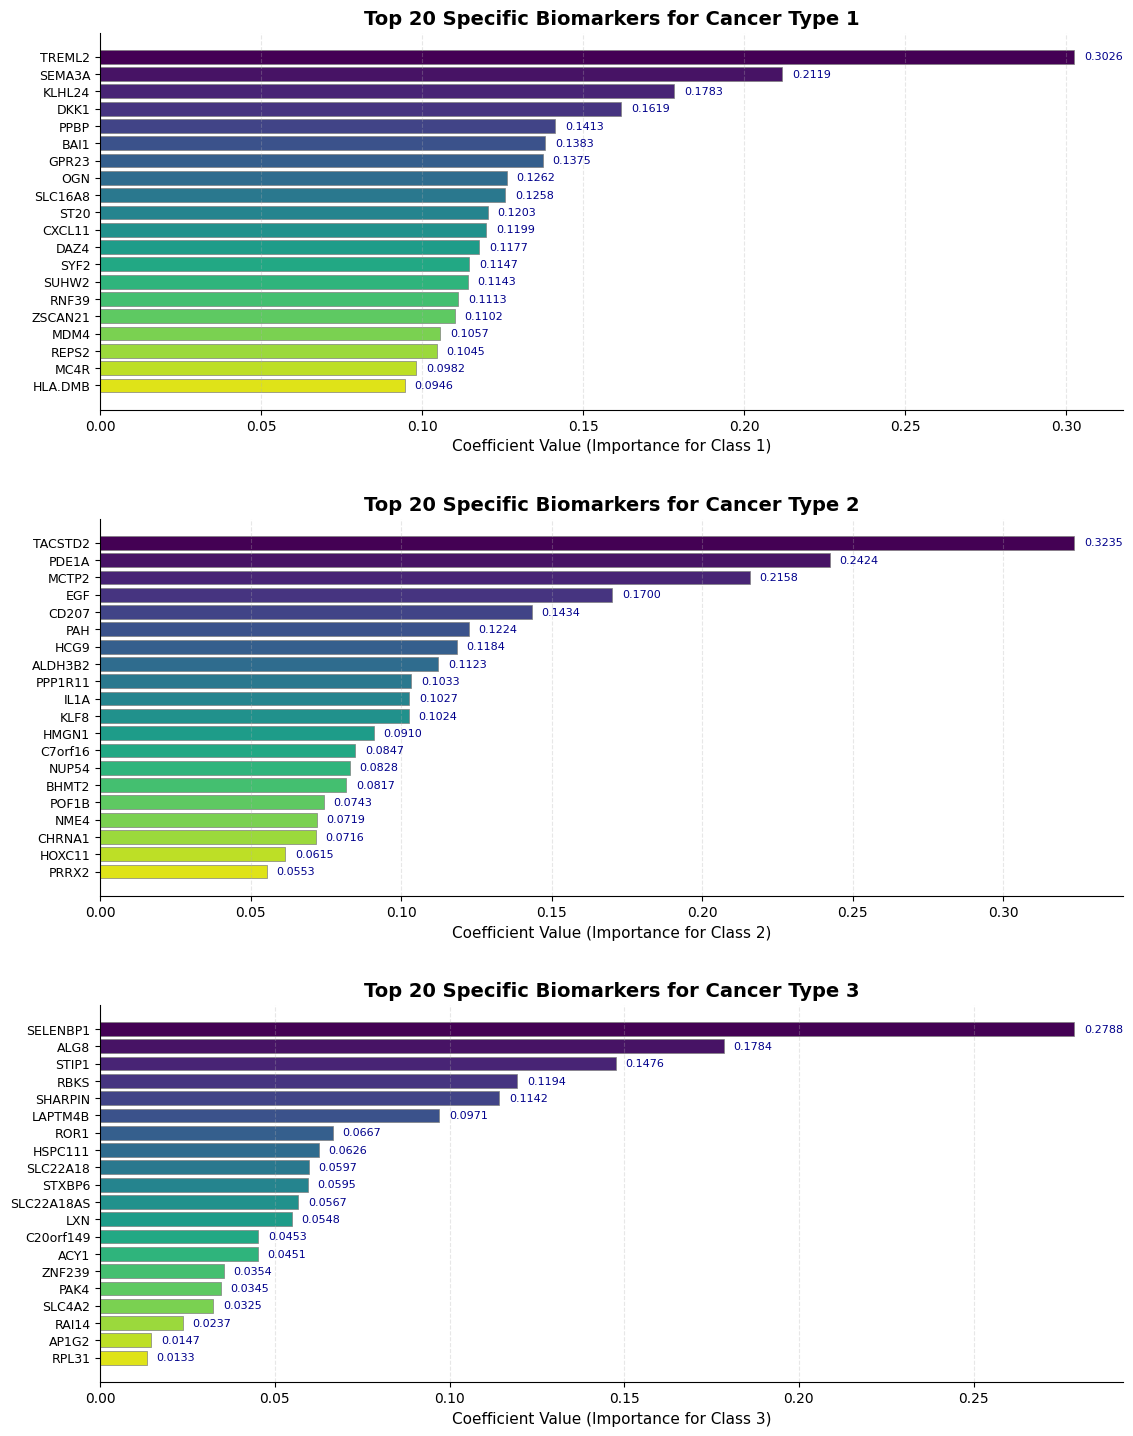

In [120]:
original_columns = X.columns
support_mask = selector.get_support()
selected_feature_names = original_columns[support_mask]
classes = best_model.classes_
coef_matrix = best_model.coef_  # Shape: (n_classes, n_features)
feature_names = selected_feature_names


TOP_N = 20  # How many features to display for each category

# Create a DataFrame to store all results for easy viewing
# Rows: genes, Columns: coefficients for each category
importance_df = pd.DataFrame(
    coef_matrix.T,
    columns=[f"Class_{c}" for c in classes],
    index=feature_names
)

results_summary = {}


fig_height = 5 * len(classes)
plt.figure(figsize=(12, fig_height))

for i, cls in enumerate(classes):
    col_name = f"Class_{cls}"

    coefs = importance_df[col_name]

    # Filter and sort positive coefficients
    positive_coefs = coefs[coefs > 0].sort_values(ascending=False)
    top_markers = positive_coefs.head(TOP_N)

    if len(top_markers) == 0:
        print(f"⚠️ No positive markers found for Class {cls}. Skipping plot.")
        continue

    results_summary[cls] = top_markers

    print(f"\n--- Top {TOP_N} Markers for Cancer Type {cls} ---")
    print(top_markers)


    ax = plt.subplot(len(classes), 1, i+1)

    cmap = plt.get_cmap('viridis')
    colors = [cmap(j / len(top_markers)) for j in range(len(top_markers))]

    # Draw a horizontal bar chart
    y_pos = np.arange(len(top_markers))
    bars = ax.barh(y_pos, top_markers.values, color=colors, edgecolor='gray', linewidth=0.5)

    # Set Y-axis labels (gene name)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_markers.index, fontsize=9)

    # Set labels and titles
    ax.set_xlabel(f'Coefficient Value (Importance for Class {cls})', fontsize=11)
    ax.set_title(f'Top {TOP_N} Specific Biomarkers for Cancer Type {cls}', fontsize=14, fontweight='bold')

    # Reverse the Y-axis (to put the most important information on top).
    ax.invert_yaxis()

    # Add grid lines (X-axis only)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add numerical labels to the right side of the bar chart.
    for j, v in enumerate(top_markers.values):

        ax.text(v + (max(top_markers.values) * 0.01), j, f'{v:.4f}', va='center', fontsize=8, color='darkblue')

plt.tight_layout(pad=3.0)
plt.show()

# interpretation for the coefficients

##### In the model, the coefficient $\beta$ means:

##### The change in the Log-Odds (log-odds) of predicting "cancer type i" for each 1 standard deviation increase in the expression level of this gene (because StandardScaler was applied), while keeping the expression levels of all other genes constant.

### Positive coefficient ($\beta > 0$)

##### Meaning: This gene is a positive marker of high expression.

##### Interpretation: The higher the expression level of this gene, the greater the probability that the sample belongs to "cancer type i".

##### Biological inference: These genes may be key factors driving the development of this type of cancer, or surface proteins/metabolic enzymes specific to this type of cell.

### Negative Coefficient ($\beta < 0 $)

##### Meaning: This gene is a negative biomarker (or repressor).

##### Interpretation: The higher the expression level of this gene, the lower the probability that the sample belongs to "cancer type i" (i.e., it is more likely to belong to other types of cancer).

##### Note: Your code only filters positive_coefs, so the Top 20 you see are all specifically highly expressed genes.

### Zero Coefficient ($\beta = 0$):

##### Meaning: This gene was removed by Elastic Net.

##### Interpretation: This gene does not provide effective information for distinguishing "cancer type i" from other types (or its information is redundant with other genes). This is the feature selection effect brought about by L1 regularization (l1_ratio close to 1).

### How to compare the size of the coefficients? (Important Premise)
Since you used StandardScaler before modeling: this means the mean of all input features becomes 0, and the standard deviation becomes 1. Direct comparison is possible: because all genes are on the same scale (standard deviation units), the magnitude of the coefficients directly reflects the importance of the features.